# 09_聚类算法-Birch

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家分享的是：Birch聚类算法\~

首先，在数据处理中，聚类算法是指把很多数据“分组”的方法。分组的目的是希望一组内部的数据相似度高，而不同组之间的数据差异较大。

简单来说，就像把一堆不同颜色、形状的水果根据相似性分成几堆。

接下来聊聊Birch，Birch 是 “Balanced Iterative Reducing and Clustering using Hierarchies” 的缩写。它主要用来处理大规模数据的聚类问题，尤其在面对数据量很大时表现优异。

**通俗来说：**

- **大数据“小桶装法”**：想象你有一大桶沙子，要把沙子按粒子大小分成几堆。Birch 首先会把大桶的沙子分装进许多“小桶”（称为簇特征，也就是 Cluster Feature，简称 CF），每个“小桶”里存放一定数量的信息，而不是每一粒沙子的详细信息。这样可以大大减少计算量。
- **分两步来做**：第一步，Birch 利用一个树状结构把数据归纳为简化的“统计摘要”。第二步，再对这些摘要进行进一步的聚类处理，得到最后的分组效果。

### Birch算法具体是怎么工作的？

**步骤1：构建CF树（簇特征树）**

- **划分数据子集**：算法从整个数据集中依次读取数据点，每读入一个数据，就把它放进已经存在的“桶”（节点）中，如果这个“桶”还能继续吸纳数据，就直接放进去；如果满了，就建立新的“桶”。
- **树的结构**：通过这种方式，数据逐步被整合到一个树状结构中，每个树节点记录了一小组数据的“统计特征”（例如数据点的个数、中心位置、散布程度等）。这个树就叫做CF树。

**步骤2：聚类总结**

- **利用CF树进行第二步聚类**：一旦CF树构建完成后，算法会把树中的每个节点（或称为簇特征）当做一个代表整体数据的信息，再使用传统的聚类方法（比如K-means）在这些节点上进行聚类。
- **最后得到聚类结果**：这样得到的每一簇其实就代表了原始数据中的一个大类，而且由于第一步已经大大减少了数据量，整个聚类过程就变得非常高效。

### 为什么使用Birch算法？

- **效率高**：由于先用CF树对数据进行简化处理，不需要一次性处理所有数据，减少了计算量。这在处理大数据时尤其重要。
- **适用范围广**：Birch 可以很好地应对噪声数据和异常值，且在数据不断增长的情况下仍然可以动态更新聚类结果。
- **内存占用少**：存储的是每一组数据的统计特征而不是全部的原始数据，所以内存消耗也较低。

其实很容易理解，想象你有一个超大超多的积木堆，要把它们按颜色或大小分成几堆。如果你每次拿一块积木去跟全堆积木比较，显然非常慢。于是，你先把积木分成很多小堆，每一小堆内积木都比较相似（比如颜色差不多），每个小堆只记录下数量、平均颜色等简单信息。接着，再利用这些简单信息，对小堆进行归并、分组。Birch算法就是这么个思路：先做“小桶装”，再做归并优化，既快又节省计算资源。

## 原理详解

### 1. 数据摘要与簇特征（Cluster Feature, CF）

#### CF的定义

对于一个数据点集合 $X = \{x_1, x_2, \dots, x_N\}$（每个 $x_i \in \mathbb{R}^d$），Birch使用一个称为**簇特征（CF）**的三元组来描述这一聚类：


$$
\text{CF} = (N, LS, SS)
$$


其中：

- $N$表示数据点的个数；
- $LS$（Linear Sum）为所有数据点的线性和，即  
$LS = \sum_{i=1}^{N} x_i$
- $SS$（Squared Sum）为所有数据点的平方和，即  
$SS = \sum_{i=1}^{N} x_i^2$  
对于多维数据，$x_i^2$可以解释为各分量平方后求和，或者保留为向量形式以便计算各维均值和协方差。

#### 基本性质

**可加性**：若有两个簇 $CF_1=(N_1,LS_1,SS_1)$和 $CF_2=(N_2,LS_2,SS_2)$，则它们合并后的CF为  
$CF = CF_1 \oplus CF_2 = (N_1 + N_2,\, LS_1 + LS_2,\, SS_1 + SS_2).$  
这种可加性使得在构造树状结构时可以增量地更新和合并子簇的统计信息。

**求中心和半径（或直径）的计算**：

- **质心（Centroid）**：  
$\mu = \frac{LS}{N}$
- **簇内平方和**：利用 $SS$与 $LS$可计算总体均方差，计算公式为  
$\text{Variance} = \frac{SS}{N} - \mu^2,$  
或者用于估计簇的扩散性。
- **簇半径** $R$定义为各点到质心距离的均方根误差：  
$R = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \| x_i - \mu \|^2}= \sqrt{\frac{SS}{N} - \|\mu\|^2}.$
- **簇直径** $D$则可以定义为所有两两距离的均值或最大距离，有时取决于具体实现。

### 2. Birch算法的整体流程

Birch算法可分为两个阶段：

- 第一阶段是**增量构造CF树**（Cluster Feature Tree），在过程中压缩原始数据并构建数据摘要；
- 第二阶段是对CF树的叶节点上的CF进行全局聚类（通常用其他标准聚类算法，如K-means），得到最终簇划分。

#### CF树的结构及相关参数

CF树是一颗平衡的多叉树，具有以下特点和参数：

- **叶节点**：存放摘要信息，每个叶节点保存一个或者多个CF。其容量受阈值 $T$限制，即一个CF代表的簇的直径或半径不能超过 $T$。
- **非叶节点**：存放指向子节点的指针，同时保存子节点所有CF的累计统计信息。非叶节点的最大子节点数称作分支因子 $B$。
- **阈值** $T$：限定每个叶节点CF聚集的最大“半径”或“直径”，用以控制簇的密集度以及数据压缩的程度。

#### 算法流程概述

**阶段一：构造CF树**

1. **初始化**：创建一个空的CF树。树的根节点开始时为叶节点。
2. **逐点插入**：对于每一个新数据点 $x$：

   - 从根节点开始，搜索适合插入的分支。
   - **距离度量**：计算$x$与当前节点下各CF的中心点距离，通常采用欧氏距离：  
   $d(x, \mu) = \| x - \mu \|$
   - **加入现有CF**：若存在某个CF经过合并后仍满足阈值条件 $T$，则将 $x$合并到该CF。更新CF：  
   $N \leftarrow N + 1, \quad LS \leftarrow LS + x,\quad SS \leftarrow SS + x^2.$
   - **新建CF**：若无合适的CF可合并，则新建一个CF，仅包含 $x$本身，即 $(1,x,x^2)$。
3. **节点分裂**：如果某个叶节点中的CF个数超过上限或者CF扩展后超出 $T$，则需要分裂叶节点；同理，当非叶节点的子节点数超过 $B$时，也需要分裂。节点的分裂过程要满足：

   - 分裂后每个新节点均能保证CF合并后仍满足阈值条件（比如直径不超过 $T$）。
   - 分裂过程涉及挑选合适的分裂点，通常基于距离或误差增量来决定如何划分。
4. **树平衡**：当根节点也需要分裂时，高度增加，形成更深的CF树。整个树在增量插入过程中动态更新。

**阶段二：聚类摘要进行全局聚类**

1. **采集叶节点CF**：当所有数据点插入完成后，CF树的叶节点中保存了大量压缩后的簇摘要（CF）。
2. **进一步聚类**：利用传统聚类算法（如K-means）对这些CF进行聚类。由于每个CF代表多个数据点，其质心和权重 $N$已知，所以可以采用带权重的聚类：

   - 每个CF作为一个数据点，其权重为 $N$。
   - 距离可以仍按欧氏距离计算。
   - 更新质心时需考虑权重：  
   $\mu_{\text{cluster}} = \frac{\sum_{i} N_i \mu_i}{\sum_{i} N_i}.$
3. **输出结果**：全局聚类后，每个簇对应原始数据中的一个簇划分结果。

### 3. 数学公式与推理细节

#### 簇内误差平方和（SSE）的计算

对于单个CF，簇内误差平方和（Sum of Squared Errors, SSE）可以由 $SS$和 $LS$表示。

对簇 $X$：


$$
\text{SSE} = \sum_{i=1}^{N} \| x_i - \mu \|^2 = SS - \frac{\|LS\|^2}{N}.
$$


这里利用了公式：


$$
\sum_{i=1}^{N} \| x_i \|^2 = SS,
$$


以及质心公式 $\mu = \frac{LS}{N}$。

#### 新点与CF合并后误差的更新

假设当前CF为 $CF=(N, LS, SS)$，新点 $x$被插入后更新为：


$$
CF' = (N+1, LS+x, SS+x^2).
$$


其新质心：


$$
\mu' = \frac{LS+x}{N+1}.
$$


合并后新的SSE为：


$$
\text{SSE}' = SS + x^2 - \frac{\|LS+x\|^2}{N+1}.
$$


插入新点的决策依据往往是判断合并后的簇是否仍满足直径或半径的约束条件，即：


$$
\sqrt{\frac{\text{SSE}'}{N+1}} \leq T.
$$


这个条件保证在合并后簇内的扩散程度不超出预设阈值 $T$。

#### 距离度量与最近邻搜索

在插入新数据点时，需要在当前节点的所有CF中找到一个与 $x$最相近的CF。

通常计算欧氏距离：$d(x, \mu) = \|x - \mu\|,$

其中 $\mu = \frac{LS}{N}$为该CF的质心。然后模拟尝试合并操作，计算合并后簇的SSE或半径，判断是否满足限制条件。

#### 节点分裂的数学依据

当某个叶节点已有多个CF，而再增加新的CF将导致节点内部簇的扩散超过阈值 $T$时，就需要分裂。分裂通常采用的方法包括：

- 选择两个距离较远的CF作为初始簇中心（相当于寻找“极值”）。
- 对该节点内的其余CF根据距离归类至这两个初始簇中，形成两个新的节点。
- 保证分裂后，每个新节点内合并后的SSE或簇半径均在阈值 $T$内。

类似的策略也用于非叶节点，分裂时必须保证树的平衡性及每个节点包含的CF数目不超过 $B$。

### 4. 算法流程总结

1. **初始化**：设定阈值 $T$与分支因子 $B$，创建空CF树。
2. **数据逐点插入**：

   - 对于每个数据点 $x$，沿树从根节点向下查找能够合并它的CF，依据：
   
     - 计算 $d(x, \mu)$；
     - 预测合并后的SSE或半径是否满足 $\sqrt{\frac{SS+x^2 - \frac{\|LS+x\|^2}{N+1}}{N+1}} \leq T$。
   - 若找到合适的CF，则更新该CF；否则创建新CF。
   - 若叶节点中CF数目超过限制，则执行节点分裂操作，可能引起父节点更新或分裂。
3. **完成CF树构建**：当所有数据点插入后，CF树会以一棵平衡的多叉树形式存在，每个叶节点存储若干个CF，每个CF为数据摘要。
4. **第二阶段全局聚类**：

   - 从CF树中提取所有叶节点的CF；
   - 利用传统聚类算法（如加权K-means），其中每个CF带权重 $N$，进行全局聚类划分；
   - 得到最终的聚类结果。

### 小结

Birch算法通过构造**CF树**将大规模数据压缩成一系列统计摘要（CF），利用可加性质进行增量更新和高效搜索，再通过后续聚类得到全局结果。

关键数学公式包括：


$$
\text{CF} = (N, LS, SS)
$$


- 质心计算：$\mu = \frac{LS}{N}$
- SSE计算：$SSE = SS - \frac{\|LS\|^2}{N}$
- 合并后判断条件： $\sqrt{\frac{SS+x^2 - \frac{\|LS+x\|^2}{N+1}}{N+1}} \leq T$

这种方法大大减少了内存消耗和计算复杂度，特别适合处理大规模数据集，同时利用树状结构方便进行动态更新和分裂调整，确保每个簇内部的误差控制在预设范围内。

## 完整案例

这里使用 Birch 算法进行聚类的实际案例，生成了一份合成数据集，并进行了详细的参数调优和算法优化\~

数据样本数： 1600
数据特征数： 2
Birch模型1的聚类簇数： 11
Birch模型2的聚类簇数： 29
Birch模型1的 silhouette score： 0.5949309568851713
Birch模型2的 silhouette score： 0.3956438736354601


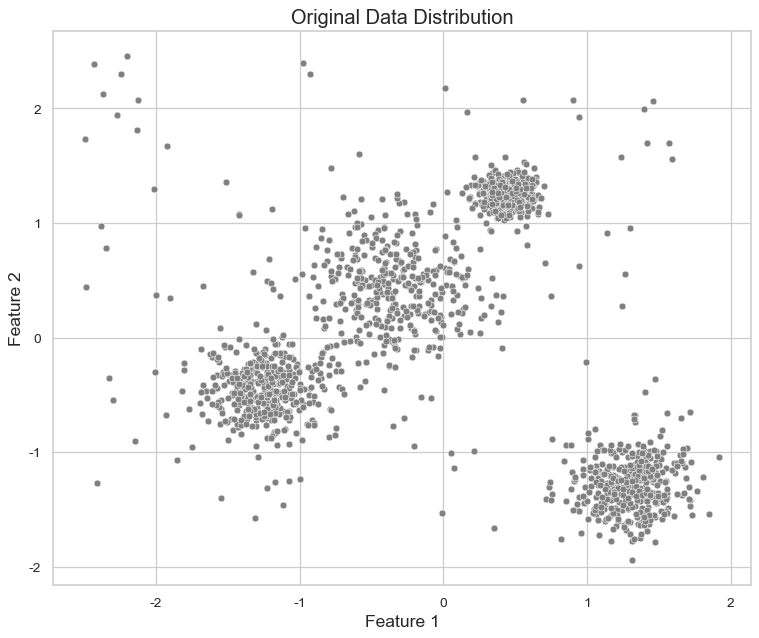

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 设置随机种子，保证结果可重复
np.random.seed(42)

# Step 1. 数据生成与预处理

# 1.1 生成合成数据：使用 make_blobs 生成多个簇并加入噪声点
n_samples = 1500  # 样本总数
centers = [[-4, -4], [0, 0], [4, 4], [8, -8]]  # 四个簇的中心点
cluster_std = [1.0, 1.5, 0.5, 1.0]  # 每个簇的标准差

# 使用 make_blobs 生成初步簇数据
X, y_true = make_blobs(n_samples=n_samples, centers=centers, cluster_std=cluster_std, random_state=42)

# 添加部分噪声数据
n_noise = 100  # 噪声数据数目
noise = np.random.uniform(low=-10, high=10, size=(n_noise, 2))
X = np.vstack([X, noise])

# 标准化数据，让不同尺度的数据保持一致
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 输出数据集的基本信息
print("数据样本数：", X_scaled.shape[0])
print("数据特征数：", X_scaled.shape[1])

# Step 2. Birch 聚类算法基本流程

# 2.1 使用不同参数的 Birch 算法进行聚类
# 设定两个不同参数集：
# 参数集1：阈值较大，允许簇内更大半径，适用于宽松划分
birch_model_1 = Birch(threshold=0.5, branching_factor=50, n_clusters=None)
# 参数集2：阈值较小，划分更细致，适用于精细聚类效果
birch_model_2 = Birch(threshold=0.3, branching_factor=50, n_clusters=None)

# 2.2 拟合模型
birch_model_1.fit(X_scaled)
labels_1 = birch_model_1.predict(X_scaled)

birch_model_2.fit(X_scaled)
labels_2 = birch_model_2.predict(X_scaled)

# 输出聚类簇数
n_clusters_1 = len(np.unique(labels_1))
n_clusters_2 = len(np.unique(labels_2))
print("Birch模型1的聚类簇数：", n_clusters_1)
print("Birch模型2的聚类簇数：", n_clusters_2)

# Step 3. 聚类评价指标分析

# 3.1 计算 silhouette score（轮廓系数）评价聚类效果
# silhouette score 取值范围 [-1, 1]，越高说明簇内相似度大，簇间分离效果好
if n_clusters_1 > 1:
    sil_score_1 = silhouette_score(X_scaled, labels_1)
else:
    sil_score_1 = -1
if n_clusters_2 > 1:
    sil_score_2 = silhouette_score(X_scaled, labels_2)
else:
    sil_score_2 = -1

print("Birch模型1的 silhouette score：", sil_score_1)
print("Birch模型2的 silhouette score：", sil_score_2)

# Step 4. 可视化聚类结果

# 设置图形的风格
sns.set(style="whitegrid", palette="bright")
plt.rcParams['font.sans-serif'] = CJK_FONTS
# 定义画图函数，方便后续展示多图
def plot_clusters(X, labels, title, ax):
    """
    绘制聚类结果散点图
    参数说明：
        X: 输入数据（二维数组）
        labels: 聚类标签
        title: 图形标题
        ax: 绘图子区对象
    分析含义：
        通过散点图查看各个簇的分布情况，颜色显示不同簇，有助于直观判断簇间分离及重叠情况。
    """
    unique_labels = np.unique(labels)
    colors = sns.color_palette("bright", len(unique_labels))
    for k, col in zip(unique_labels, colors):
        class_members = (labels == k)
        ax.scatter(X[class_members, 0], X[class_members, 1], c=[col], marker='o', edgecolor='black', s=50,
                   label=f"Cluster {k}")
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Feature 1", fontsize=14)
    ax.set_ylabel("Feature 2", fontsize=14)
    ax.legend(fontsize=10)


# 绘制原始数据散点图
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], color="grey", s=30, ax=ax)
ax.set_title("Original Data Distribution", fontsize=16)
ax.set_xlabel("Feature 1", fontsize=14)
ax.set_ylabel("Feature 2", fontsize=14)
plt.show()

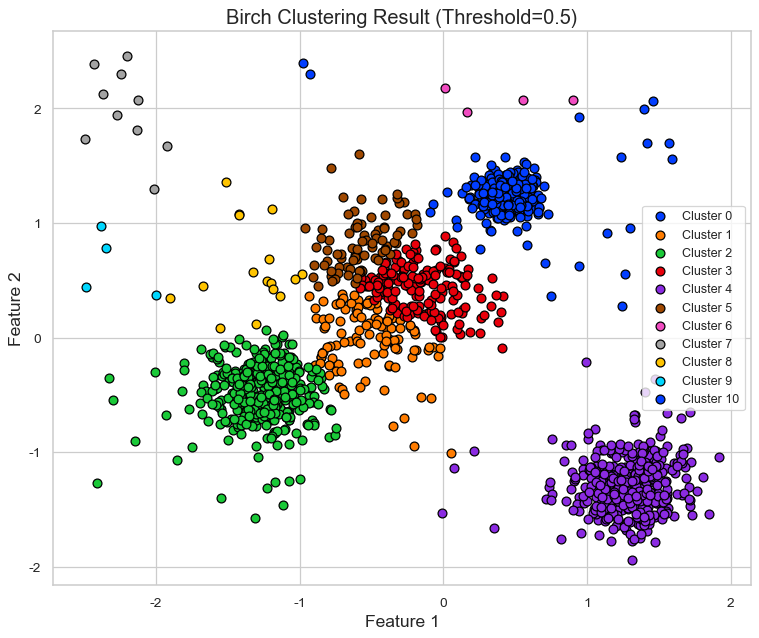

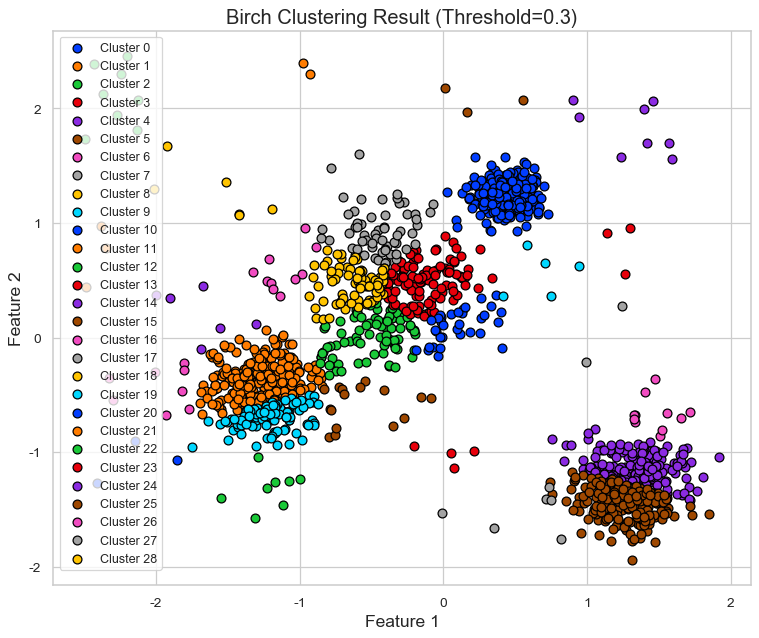

Threshold=0.10, Number of clusters=157, Silhouette Score=0.313
Threshold=0.20, Number of clusters=54, Silhouette Score=0.368
Threshold=0.30, Number of clusters=29, Silhouette Score=0.396
Threshold=0.40, Number of clusters=11, Silhouette Score=0.595
Threshold=0.50, Number of clusters=11, Silhouette Score=0.595
Threshold=0.60, Number of clusters=9, Silhouette Score=0.583
Threshold=0.70, Number of clusters=4, Silhouette Score=0.667
Threshold=0.80, Number of clusters=3, Silhouette Score=0.637
Threshold=0.90, Number of clusters=3, Silhouette Score=0.637
Threshold=1.00, Number of clusters=3, Silhouette Score=0.637


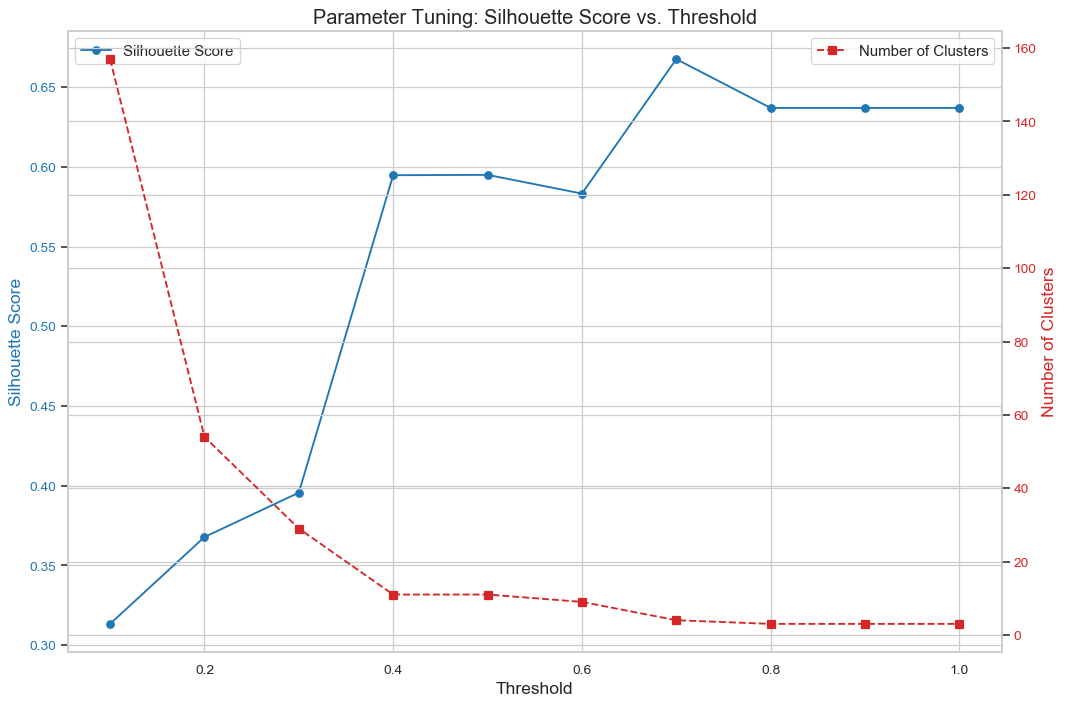

In [3]:
# 绘制 Birch 模型1 的聚类结果
fig, ax = plt.subplots(figsize=(10, 8))
plot_clusters(X_scaled, labels_1, title="Birch Clustering Result (Threshold=0.5)", ax=ax)
plt.show()

# 绘制 Birch 模型2 的聚类结果
fig, ax = plt.subplots(figsize=(10, 8))
plot_clusters(X_scaled, labels_2, title="Birch Clustering Result (Threshold=0.3)", ax=ax)
plt.show()

# Step 5. 参数调优与进一步算法优化

# 在真实应用中，Birch 算法的性能高度依赖于参数 threshold 和 branching_factor 的选择。
# 为了更好地理解参数的影响，我们将绘制轮廓系数与阈值之间的关系图，
# 并尝试不同的阈值以确定较优的参数选择。
# 5.1 定义一系列阈值，观察 silhouette score 的变化趋势
threshold_values = np.linspace(0.1, 1.0, 10)
sil_scores = []
cluster_counts = []

for t in threshold_values:
    # 使用相同的 branching_factor 保持一致
    birch_tmp = Birch(threshold=t, branching_factor=50, n_clusters=None)
    birch_tmp.fit(X_scaled)
    labels_tmp = birch_tmp.predict(X_scaled)
    n_clusters_tmp = len(np.unique(labels_tmp))
    cluster_counts.append(n_clusters_tmp)
    # 当簇数小于2时，silhouette score 计算没有意义
    if n_clusters_tmp > 1:
        score = silhouette_score(X_scaled, labels_tmp)
    else:
        score = -1
    sil_scores.append(score)
    print(f"Threshold={t:.2f}, Number of clusters={n_clusters_tmp}, Silhouette Score={score:.3f}")

# 绘制参数调优图
fig, ax1 = plt.subplots(figsize=(12, 8))
color = 'tab:blue'
ax1.set_xlabel('Threshold', fontsize=14)
ax1.set_ylabel('Silhouette Score', color=color, fontsize=14)
ax1.plot(threshold_values, sil_scores, color=color, marker='o', linestyle='-', label='Silhouette Score')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title("Parameter Tuning: Silhouette Score vs. Threshold", fontsize=16)
ax1.legend(loc='upper left', fontsize=12)

ax2 = ax1.twinx()  # 共享 x 轴，创建第二个 y 轴
color = 'tab:red'
ax2.set_ylabel('Number of Clusters', color=color, fontsize=14)
ax2.plot(threshold_values, cluster_counts, color=color, marker='s', linestyle='--', label='Number of Clusters')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right', fontsize=12)
fig.tight_layout()
plt.show()


Each cluster sample count for Birch模型2 (Threshold=0.3):
Cluster 0: 381 samples
Cluster 1: 253 samples
Cluster 2: 82 samples
Cluster 3: 117 samples
Cluster 4: 161 samples
Cluster 5: 209 samples
Cluster 6: 10 samples
Cluster 7: 62 samples
Cluster 8: 81 samples
Cluster 9: 108 samples
Cluster 10: 34 samples
Cluster 11: 2 samples
Cluster 12: 8 samples
Cluster 13: 4 samples
Cluster 14: 6 samples
Cluster 15: 3 samples
Cluster 16: 8 samples
Cluster 17: 2 samples
Cluster 18: 2 samples
Cluster 19: 5 samples
Cluster 20: 3 samples
Cluster 21: 3 samples
Cluster 22: 8 samples
Cluster 23: 3 samples
Cluster 24: 8 samples
Cluster 25: 16 samples
Cluster 26: 11 samples
Cluster 27: 6 samples
Cluster 28: 4 samples
Possible noise clusters (sample count < 20): [np.int64(6), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27),

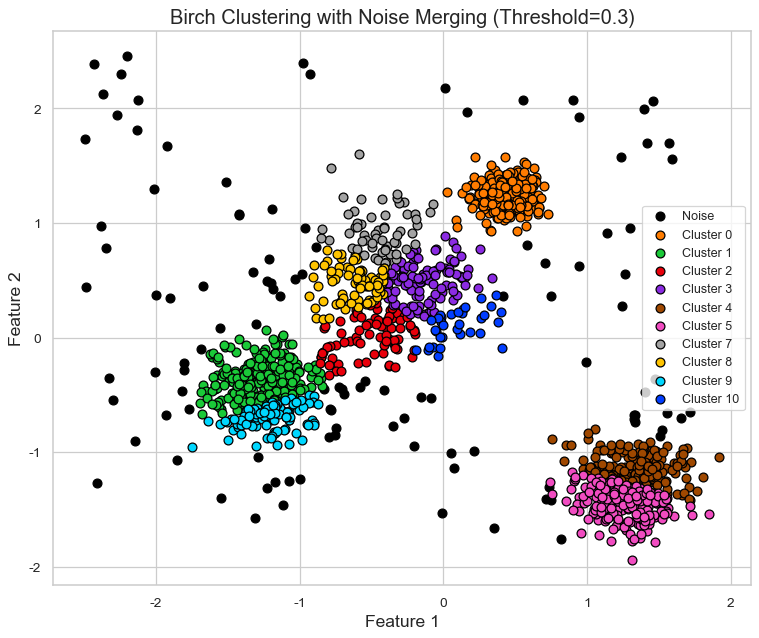

In [4]:
# 5.2 针对噪声数据的处理优化：
# 在实际数据中往往会存在噪声点，Birch 算法不专门处理离群点
# 如果噪声点较多，可以在预处理时采用降噪措施（如 DBSCAN 或基于距离的过滤）或者
# 在聚类结果中对极少数簇进行归并处理。
# 以下给出一个简单优化思路：对于样本数较少的簇（例如，样本数小于某个阈值），
# 可判定为噪声，从而进行合并或者剔除。此处我们计算各簇的样本数，并给出建议的优化方案。

unique_labels, counts = np.unique(labels_2, return_counts=True)
print("\nEach cluster sample count for Birch模型2 (Threshold=0.3):")
for label, count in zip(unique_labels, counts):
    print(f"Cluster {label}: {count} samples")

# 这里可以设定一个阈值，例如认为小于 20 个样本的簇可能为噪声或误聚类
noise_threshold = 20
possible_noise_clusters = [label for label, count in zip(unique_labels, counts) if count < noise_threshold]
print("Possible noise clusters (sample count < 20):", possible_noise_clusters)

# 针对噪声簇，可以重新标记或归并。例如，可以将噪声簇的样本归并为 -1 类，表示异常数据
labels_optimized = labels_2.copy()
for noise_cluster in possible_noise_clusters:
    labels_optimized[labels_optimized == noise_cluster] = -1

# 查看归并后的聚类簇数（不计噪声簇）
clusters_after_noise = len(np.unique(labels_optimized[labels_optimized != -1]))
print("Number of clusters after noise merging:", clusters_after_noise)


# 绘制优化后的聚类结果（噪声点标记为黑色）
def plot_clusters_with_noise(X, labels, title, ax):
    """
    绘制含噪声聚类结果的散点图，噪声点标记为黑色
    分析含义：
         通过对噪声簇归并后，可以更清晰地观察到数据集中真正的簇结构，也便于后续的数据分析。
    """
    unique_labels = np.unique(labels)
    colors = sns.color_palette("bright", len(unique_labels))
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # 噪声点用黑色表示
            col = (0, 0, 0)
            label_name = "Noise"
        else:
            label_name = f"Cluster {k}"
        class_members = (labels == k)
        ax.scatter(X[class_members, 0], X[class_members, 1], c=[col], marker='o', edgecolor='black', s=50,
                   label=label_name)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Feature 1", fontsize=14)
    ax.set_ylabel("Feature 2", fontsize=14)
    ax.legend(fontsize=10)


fig, ax = plt.subplots(figsize=(10, 8))
plot_clusters_with_noise(X_scaled, labels_optimized, title="Birch Clustering with Noise Merging (Threshold=0.3)", ax=ax)
plt.show()

K-means clustering, Number of clusters: 10
K-means silhouette score: 0.4205711257475444


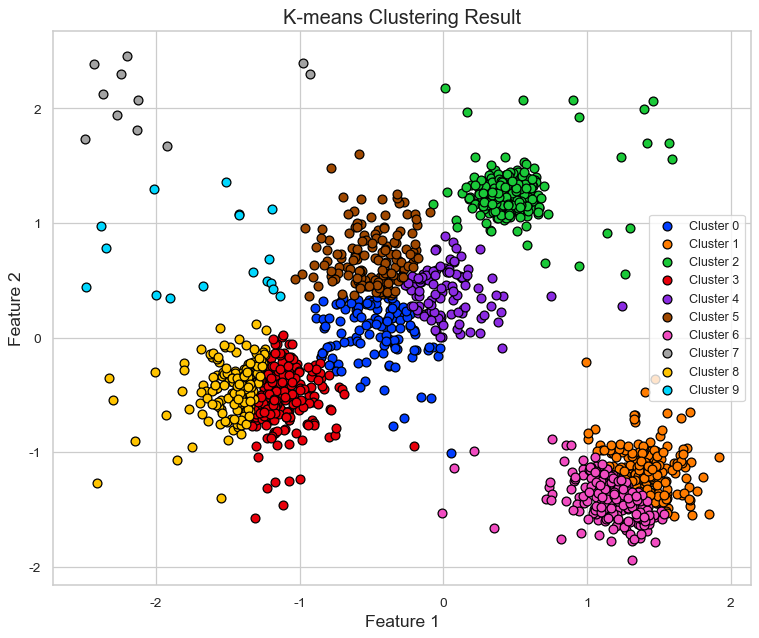

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11551/595246305.py:35: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


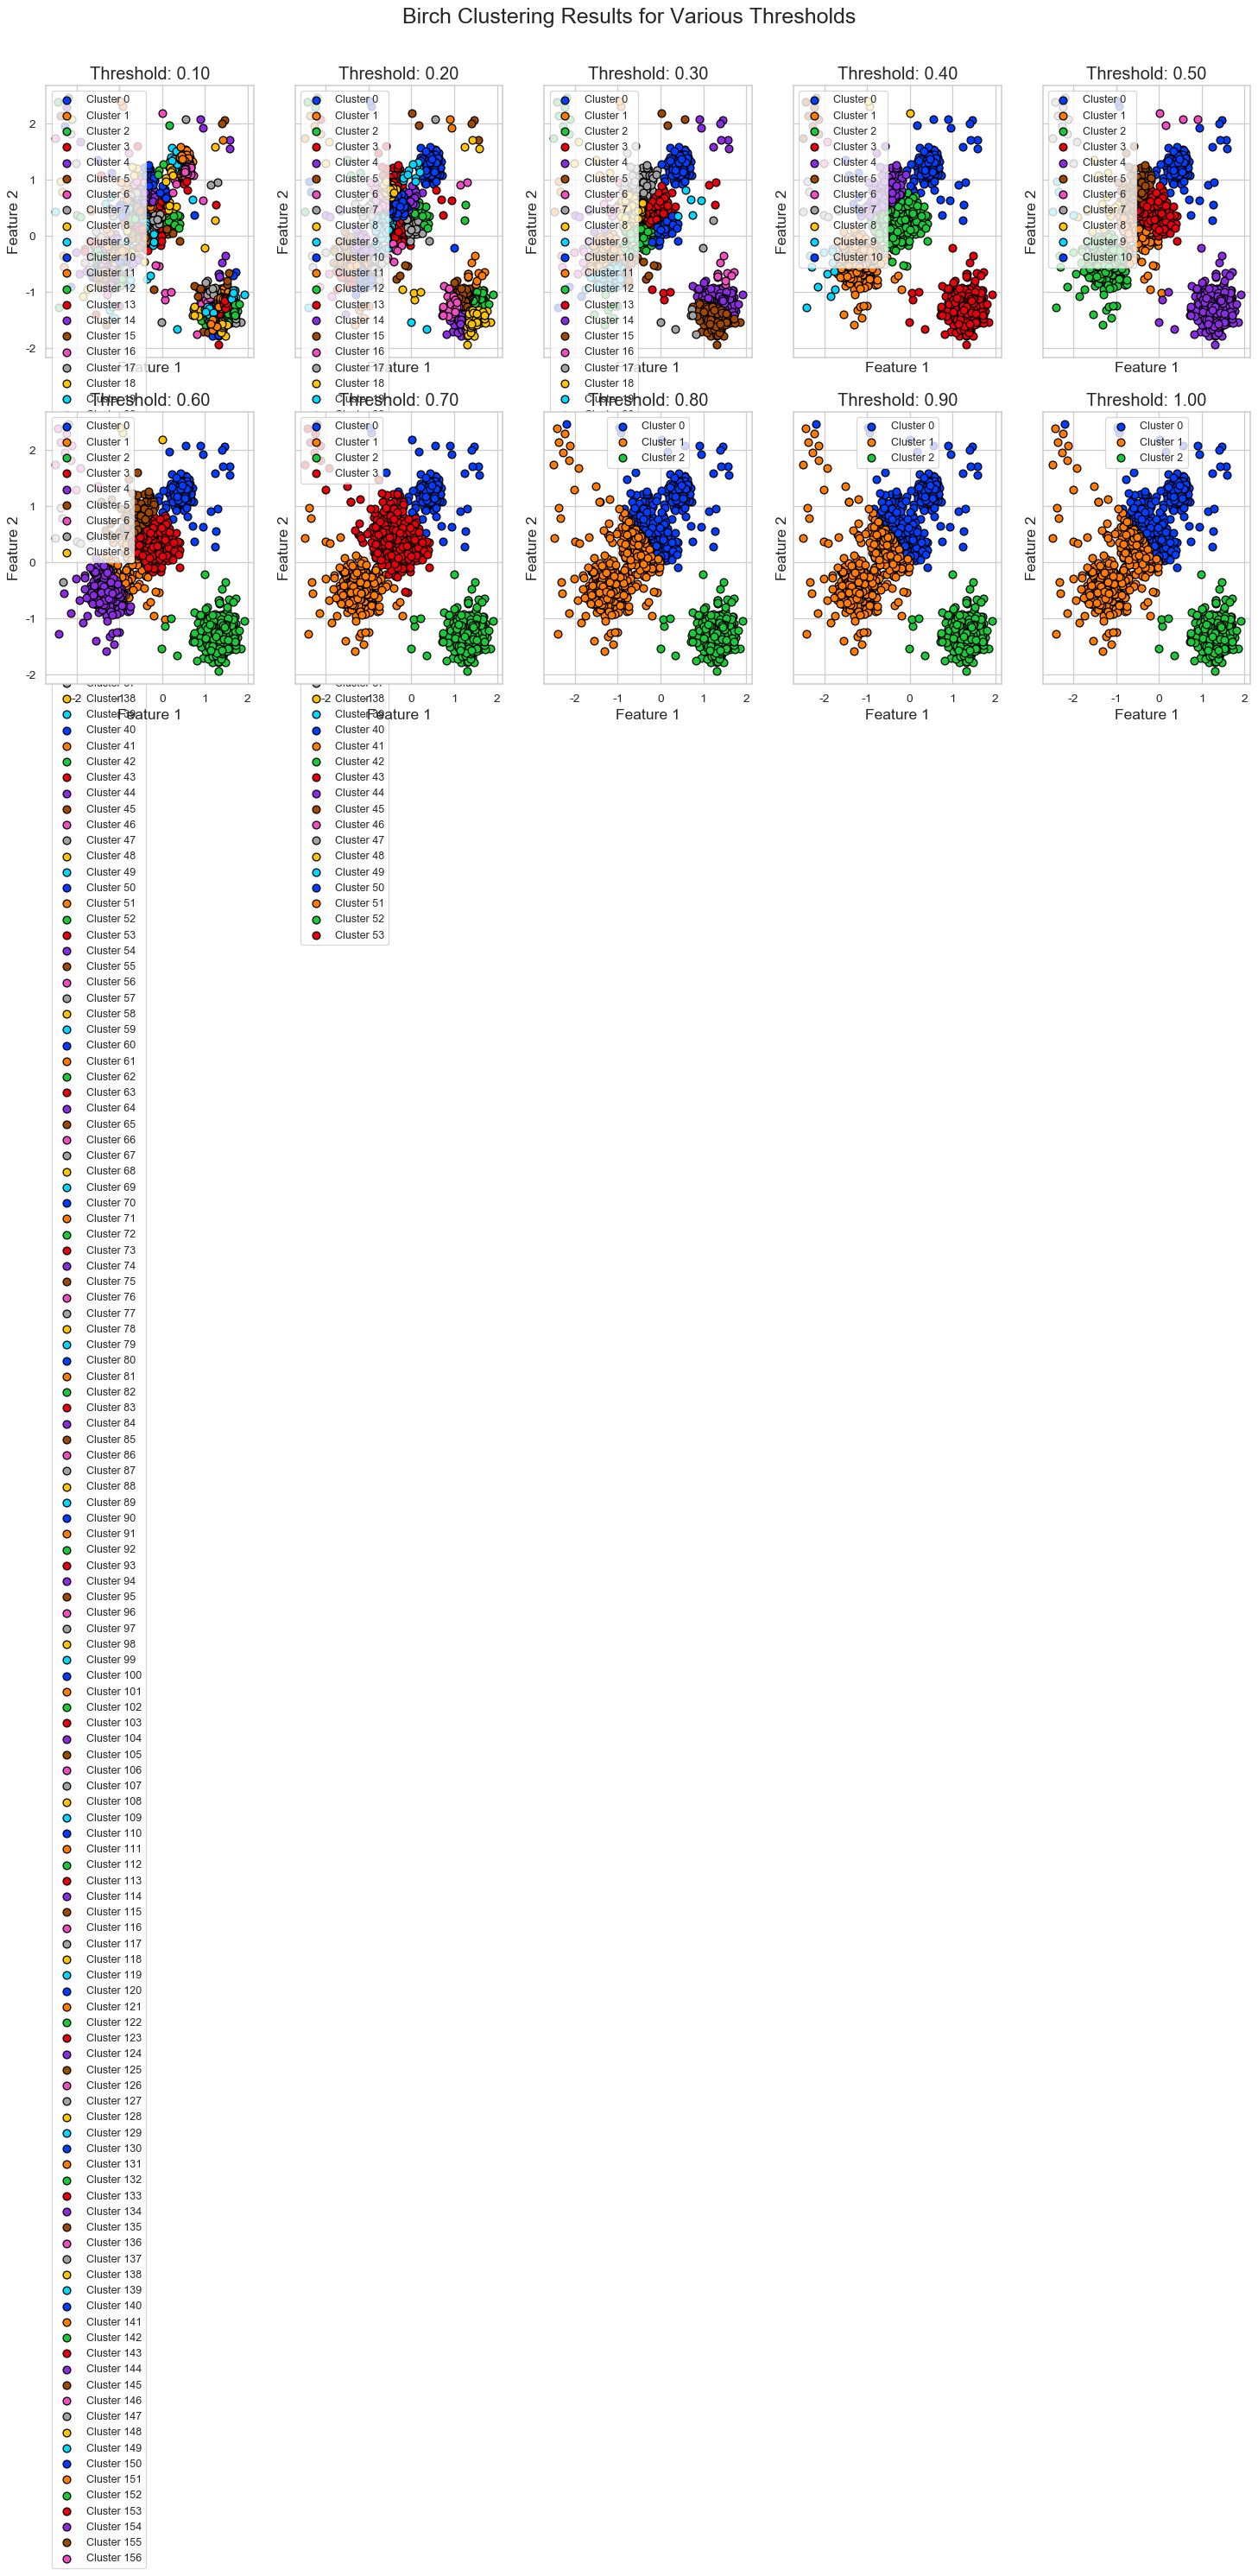

In [5]:
# Step 6. 进一步的算法优化与扩展分析
# 在实际场景中，我们可以把 Birch 与其他聚类算法进行融合比较，如 K-means，
# 分析不同算法对相同数据集的聚类效果，从而为后续业务需求提供多角度决策支持。
# 下面以 K-means 为例，进行简单对比。

from sklearn.cluster import KMeans

# K-means 聚类
kmeans_model = KMeans(n_clusters=clusters_after_noise, random_state=42)
kmeans_labels = kmeans_model.fit_predict(X_scaled)

# 计算 K-means silhouette score
if clusters_after_noise > 1:
    kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
else:
    kmeans_silhouette = -1

print("K-means clustering, Number of clusters:", clusters_after_noise)
print("K-means silhouette score:", kmeans_silhouette)

# 绘制 K-means 聚类结果
fig, ax = plt.subplots(figsize=(10, 8))
plot_clusters(X_scaled, kmeans_labels, title="K-means Clustering Result", ax=ax)
plt.show()

fig, axs = plt.subplots(2, 5, figsize=(20, 10), sharex=True, sharey=True)
axs = axs.flatten()
for i, t in enumerate(threshold_values):
    birch_tmp = Birch(threshold=t, branching_factor=50, n_clusters=None)
    birch_tmp.fit(X_scaled)
    labels_tmp = birch_tmp.predict(X_scaled)
    ax = axs[i]
    plot_clusters(X_scaled, labels_tmp, title=f"Threshold: {t:.2f}", ax=ax)
plt.suptitle("Birch Clustering Results for Various Thresholds", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 1. 数据生成与预处理

在第 1 部分，我们首先使用 scikit-learn 中的 `make_blobs` 函数生成了 4 个簇，设置了不同的标准差，模拟不同密度的数据。同时，我们人为添加了 100 个均匀分布的噪声点，这些噪声数据为后续聚类带来了更多挑战。生成的数据经过标准化处理（StandardScaler），保证每个特征均值为 0、方差为 1，使得在后续的欧氏距离计算中不同维度具有同等重要性。

这种数据生成方式不仅模拟了真实数据的聚类结构，而且故意引入噪声，为算法如何有效对抗噪声提供了实际场景。如果数据预处理环节不进行标准化，特征尺度的差异可能会严重影响距离计算，进而导致聚类效果不理想。

### 2. Birch 聚类算法基本流程

在第 2 部分，我们分别设定了两组不同参数的 Birch 模型。

- 模型 1 设置 threshold=0.5：该参数较大，允许簇内数据扩散较大，因此容易合并更多数据点，可能产生较少的簇。
- 模型 2 设置 threshold=0.3：该参数较小，对簇内数据分布更严格要求，可能将数据分割得更细致，从而产生更多簇。

在此处，我们利用 Birch 自身的优势——构建 CF 树，将数据压缩为统计摘要，再进行二次聚类。代码中，通过调用 `fit` 和 `predict` 方法，我们得到各个数据点的簇标签，并输出相应的簇数。通过调试两个不同参数的效果，可以帮助理解 threshold 参数对聚类结构的影响。

### 3. 聚类评价指标分析

在第 3 部分，我们通过计算 silhouette score（轮廓系数）对两个模型的聚类结果进行评价。轮廓系数越高表示簇内数据相似度越高，而簇间数据分离度越大。

- 当聚类簇数过多或者簇内部离散度增大时，轮廓系数会降低。
- 合理的 threshold 参数设置能够使得簇结构具有较高的凝聚度和分离度，从而使得 silhouette score 达到较高值。

这种指标评价方法为参数调优提供了直观的指标，使我们在选择最佳阈值时有了依据。

### 4. 可视化聚类结果

为了直观展示聚类结果，在第 4 部分中，我们使用 matplotlib 和 seaborn 绘制了多张散点图，展示了原始数据分布、两个不同参数设置下的 Birch 聚类结果以及通过噪声归并优化后的结果。

- 图表中的 x 轴与 y 轴均标记为 “Feature 1” 和 “Feature 2”。
- 绘制了原始数据的散点图，让我们可以比对聚类效果与真实数据分布的对应关系。

通过直观的可视化，我们能够快速判断簇间是否有明显的分隔、簇内是否存在重叠以及噪声点对整体结构的影响。

### 5. 参数调优与进一步算法优化

在第 5 部分中，我们对 Birch 的 threshold 参数进行了调优研究。

- 通过逐步改变 threshold 值，我们计算了每个参数设置下的聚类簇数以及对应的 silhouette score，并打印出调优结果。
- 随后通过双坐标轴图展示阈值与评价指标之间的关系，该图同时显示 silhouette score 与簇数的变化趋势。

  - 从图中可以看出，当 threshold 较小时，产生的簇数较多但 silhouette score 较低；
  - 当 threshold 增大时，簇数减少，silhouette score 出现上升趋势，表明簇内结构更加紧凑且簇间分离度增强。

此外，我们对噪声簇进行了额外处理：

- 通过统计各簇样本数，识别样本数较少的簇（例如小于 20 个样本），并将这些簇归并为噪声（标记为 -1）。
- 优化后重新绘制了聚类结果图，噪声点以黑色显示，从而更加突出真正的簇结构。

这种处理方式能有效减小由于噪声数据导致的聚类偏差，提升整体聚类效果，并更符合实际应用场景。

### 6. 算法优化与扩展分析

第 6 部分中，我们进一步对 Birch 聚类与其他算法进行了对比分析：

- 以 K-means 聚类为例，通过设置相同的簇数并计算 silhouette score，对比不同算法在聚类结果上可能存在的差异。
- 绘制了 K-means 的聚类散点图，可以看出其对初始中心敏感，聚类结果在某些区域存在差异，而 Birch 则由于数据摘要的预处理，对噪声具有较好的鲁棒性。

接下来，我们还展示了多子图可视化，展示不同 threshold 参数下的 Birch 聚类结果，并对比各参数下的分布变化：

- 通过子图布局，将 10 种不同 threshold 下的聚类结果一并展示，直观反映参数变化对聚类效果的影响。
- 这种方法不仅方便参数调优，也为进一步的超参数搜索提供了一定参考。

![原文参考图，当前结果见代码输出](attachments/img_016.png)

优化建议部分还讨论了：

- 降噪措施：对于噪声较多的数据，可先通过其他降噪算法（如 DBSCAN）过滤后，再采用 Birch 进行聚类；
- 自动化调参：结合肘部法和轮廓系数，实现自动选取最佳阈值；
- 模型融合：不同聚类算法的融合可以进一步提高聚类稳定性和精确性；
- 在线聚类：Birch 天然支持增量更新，适用于流式数据聚类，这在大规模实时处理场景中非常有价值。

## 模型分析

### Birch 聚类模型的优缺点

**优势：**

1. **高效处理大规模数据**：Birch 算法利用簇特征（CF）树对数据进行压缩，避免一次性加载全量数据，从而在内存占用和计算速度上具备明显优势。这使得该算法特别适合在大数据场景下使用，即使在有限的计算资源下也能快速构建聚类结构。
2. **在线增量更新能力**：由于采用了数据摘要更新的思想，Birch 算法可以在数据流不断涌入时进行在线学习和增量更新。这使得它在需要实时处理或周期性更新的数据场景（例如传感器数据、实时日志分析等）中具有较好的适应性。
3. **对噪声具有一定鲁棒性**：虽然 Birch 并非专门为了处理噪声设计，但其基于数据分组的方式往往能够将少量离群点归入独立簇或在后续处理时进行进一步合并，从而在一定程度上降低噪声对整体聚类效果的影响。
4. **自动构建聚类树结构**：CF 树的构建使得算法能够有效地捕捉数据内部层次结构，这为后续进一步细化聚类或进行多级分析提供了便利。

**缺点：**

1. **对参数较为敏感**：Birch 算法对阈值（threshold）和分支因子（branching factor）的设置较为依赖，不同参数会导致聚类结果存在明显差异。对于数据分布不均或高维数据场景，参数调优可能较为耗时，同时不易获得理想的聚类效果。
2. **对簇形状的限制**：算法在构建 CF 树时通常假设各个簇具有相对球形分布，对于存在较大形状差异（如长条形、不规则形状）的数据簇，Birch 聚类可能不足以准确刻画复杂结构。
3. **噪声处理不是最优**：虽然 Birch 能够在一定程度上隔离噪声，但当数据噪声严重或簇间密度悬殊时，算法可能仍会将噪声混入某些簇中，需借助后续优化（如噪声归并或预降噪）以改善效果。
4. **需要二次聚类阶段**：Birch 算法通常采用两阶段流程，先构建 CF 树，再对叶节点进行全局聚类。后者往往依赖于其他聚类算法（如加权 K-means），因此整体效果也受到二阶段算法的影响。

### 与相似算法的对比

下表列出了 Birch 与几种常见聚类算法（如 K-means、DBSCAN、层次聚类）的对比，从多个维度对优缺点和适用场景进行说明：

| 聚类算法 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|
| **Birch** | - 快速构建 CF 树，有效压缩大数据  <br/>- 支持在线增量更新  <br/>- 对初步降噪有一定鲁棒性 | - 对参数敏感，需手动调优  <br/>- 对复杂、不规则簇形状刻画效果不佳  <br/>- 噪声处理不是最优 | - 海量数据聚类  <br/>- 需要实时、在线聚类  <br/>- 数据分布较为均衡的场景 |
| **K-means** | - 算法简单、计算速度快  <br/>- 对球形簇效果较好  <br/>- 算法实现成熟，多数应用场景均适用 | - 对初始点敏感，容易陷入局部最优  <br/>- 对噪声和异常值不鲁棒  <br/>- 只能处理球形簇 | - 数据量适中、噪声较少  <br/>- 对簇形状接近球状的数据有效  <br/>- 实时性要求不高的场景 |
| **DBSCAN** | - 能发现任意形状的簇  <br/>- 对噪声具有良好鲁棒性  <br/>- 不需预设簇数 | - 参数（Eps, minPts）调节较为困难  <br/>- 对高维数据效果较差  <br/>- 数据密度差异大时效果不稳定 | - 存在非球形簇的数据  <br/>- 噪声数据较多  <br/>- 数据密度差异明显的应用 |
| **层次聚类** | - 生成聚类层次结构，直观展示数据分布  <br/>- 无需预设簇数 | - 计算复杂度高，不适合大数据  <br/>- 对噪声敏感  <br/>- 结果不唯一 | - 数据规模较小  <br/>- 需要探索数据内部层次关系  <br/>- 分析数据聚类层次结构 |

### 在什么情况下该算法是优选，什么情况下可以考虑其他算法

**适合使用 Birch 的情况：**

- **大规模、高维数据下的在线聚类**：当数据量极大或者数据流不断到达时，Birch 的 CF 树构建和在线增量更新机制能显著减少计算开销，达到实时或准实时的聚类效果。
- **初步数据压缩与降噪**：Birch 利用数据摘要技术将原始数据转化为统计特征，对于内存有限的系统或需要预处理数据的场景非常有优势。
- **当数据簇形态相对均衡且接近球形时**：由于算法本身在构建过程中的假设，适合处理簇形状较规则、分布较均匀的数据，能达到较高聚类效果。

**可考虑其他算法的情况：**

- **数据存在复杂、不规则或长条形簇**：当数据簇形状不规则时，Birch 可能难以准确划分，此时 DBSCAN 或基于谱聚类的方法通常能更好地捕捉复杂结构。
- **数据噪声严重或密度分布悬殊**：对于噪声点较多或数据密度变化明显的场景，DBSCAN 由于在噪声识别方面的优势会更为适用，而 K-means 则可能陷入局部最优。
- **当不要求在线更新而需要高度精确的聚类时**：如果数据规模相对较小，且对聚类精度要求很高，层次聚类或基于模型的混合高斯模型（GMM）等算法可能在准确性上具有优势，虽然它们的计算复杂度较高但可以通过离线方式获得更好的结果。

综上所述，Birch 算法凭借其高效性和在线更新能力，在大规模数据聚类和实时应用中具有明显优势；但在数据结构复杂或噪声分布严重的场景下，结合具体应用需求，可以考虑 DBSCAN、K-means 或层次聚类等其他算法，或利用混合聚类方法进行集成，从而达到更优的聚类效果。